## Problem Set 4
PHYSGR5084 Quantum Simulation and Computing Lab

Daniel Vitenko

In [35]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

%matplotlib inline

# Problem 3e

In [36]:
def ising_hamiltonian(N, J, h):
    terms = []

    # ZZ interactions
    for i in range(N-1):
        z_str = ['I'] * N
        z_str[i] = 'Z'
        z_str[i+1] = 'Z'
        terms.append(("".join(z_str), -J))

    # X field
    for i in range(N):
        x_str = ['I'] * N
        x_str[i] = 'X'
        terms.append(("".join(x_str), -h))

    return SparsePauliOp.from_list(terms)

# Problem 5d

In [24]:
def build_time_evo_circuit(qc, steps, delta_t, J, h):
    for _ in range(steps):
        # RXX block
        qc.h(0); qc.h(1)
        qc.cx(0, 1)
        qc.rz(-2*J*delta_t, 1)
        qc.cx(0, 1)
        qc.h(0); qc.h(1)

        qc.barrier()
        
        # RYY block
        qc.sdg(0); qc.h(0)
        qc.sdg(1); qc.h(1)
        qc.cx(0, 1)
        qc.rz(-2*J*delta_t, 1)
        qc.cx(0, 1)
        qc.h(0); qc.s(0)
        qc.h(1); qc.s(1)

        qc.barrier()

        # RZ block
        qc.rz(-2*h*delta_t, 0)
        qc.rz(-2*h*delta_t, 1)

        if _ < steps - 1:
            qc.barrier()
    
    qc.measure_all()


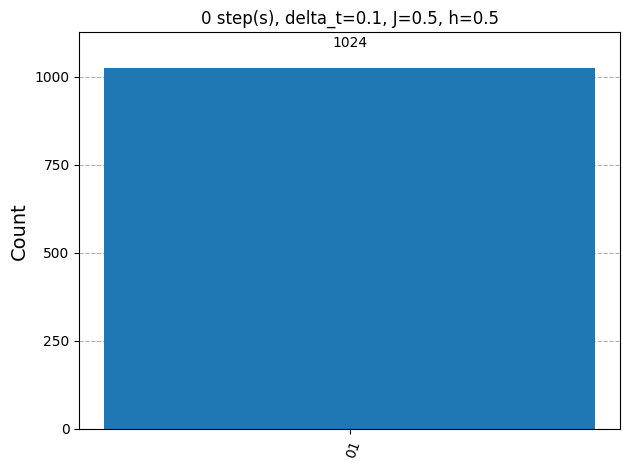

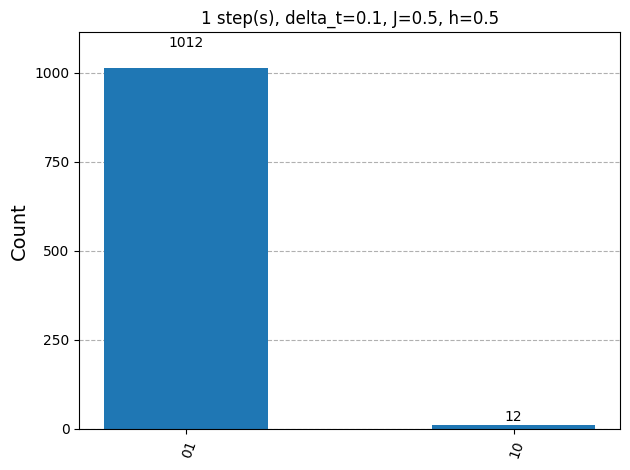

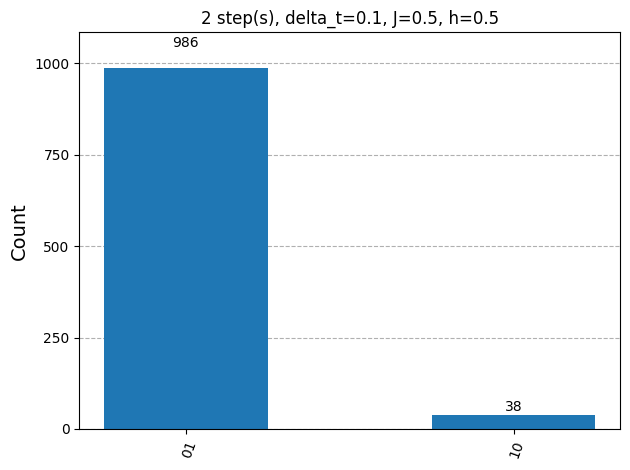

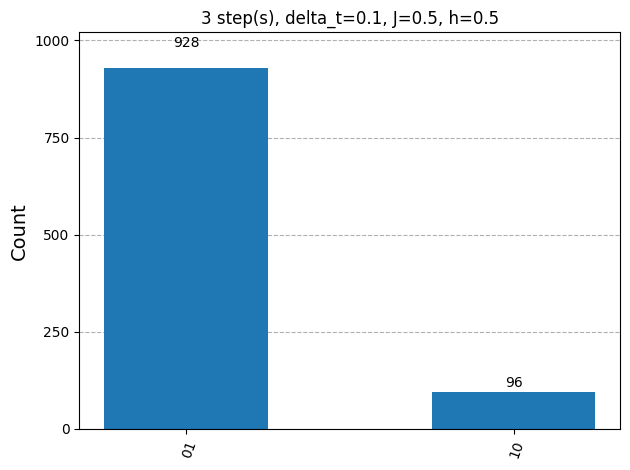

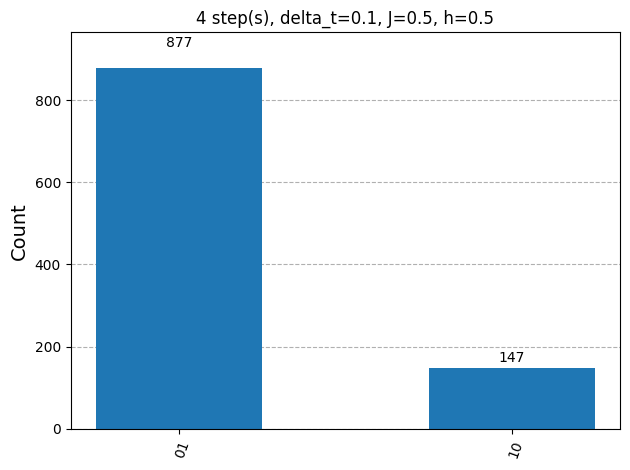

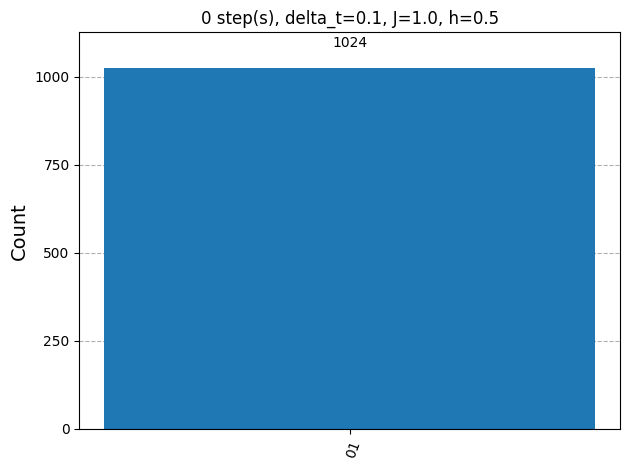

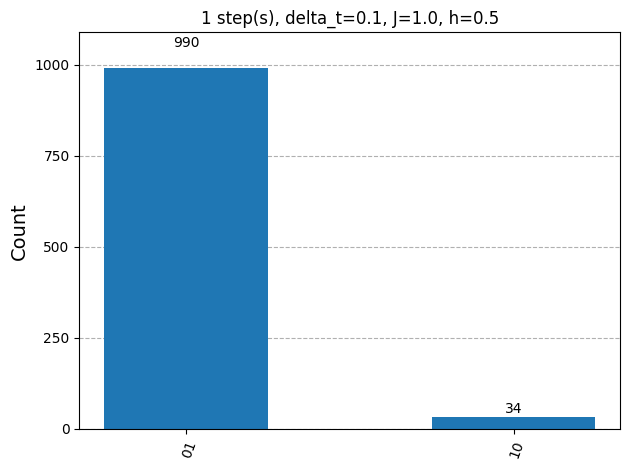

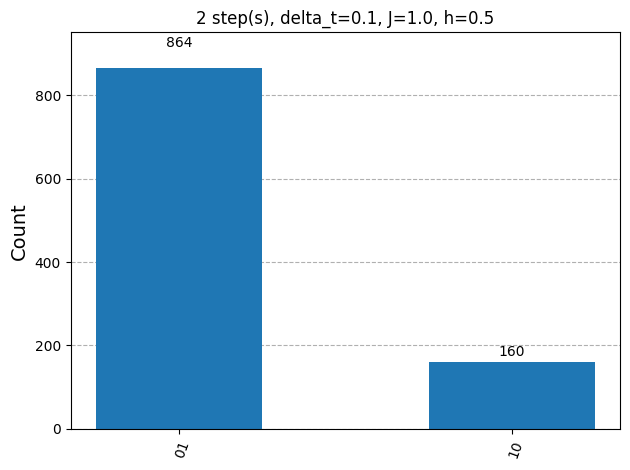

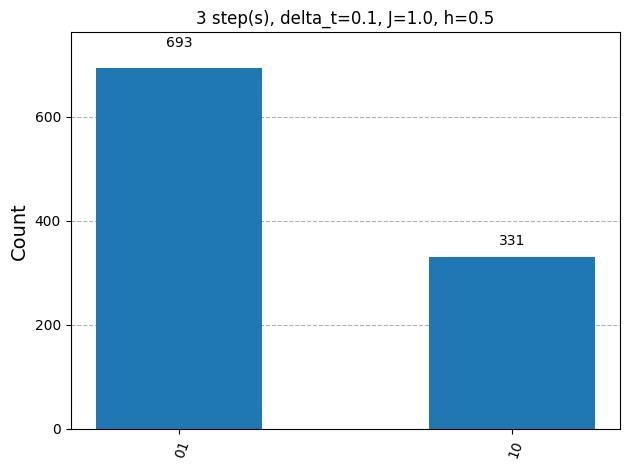

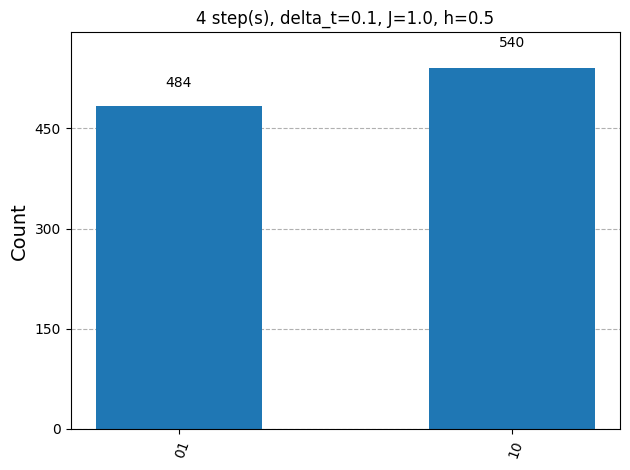

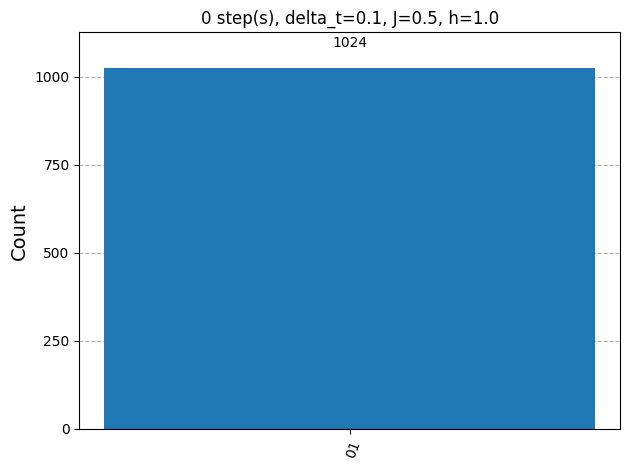

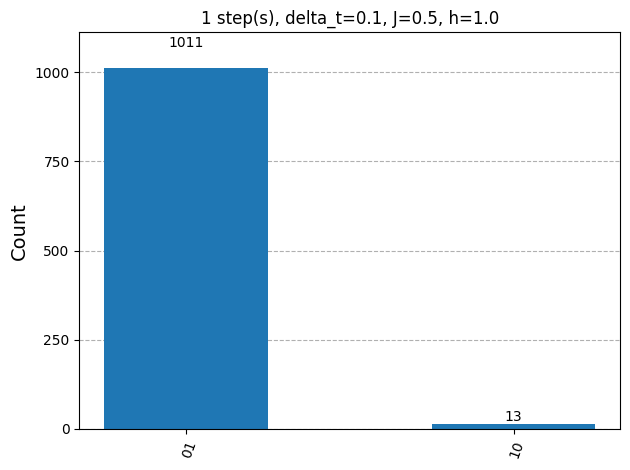

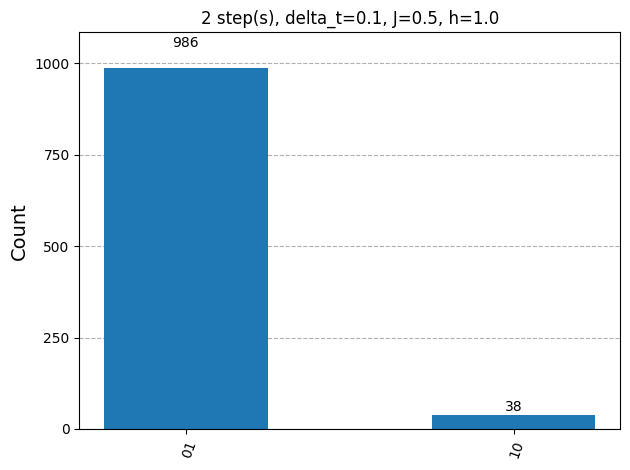

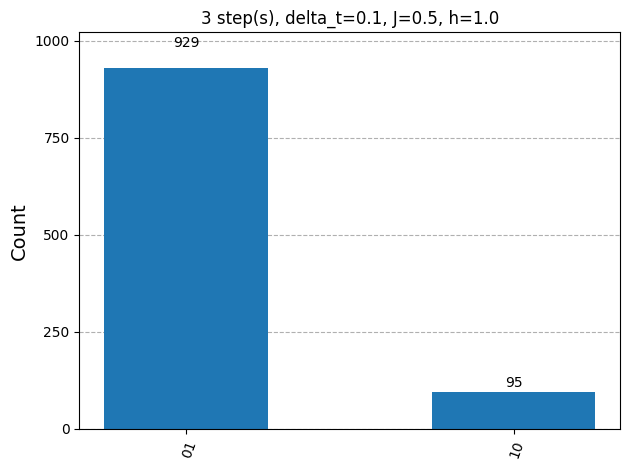

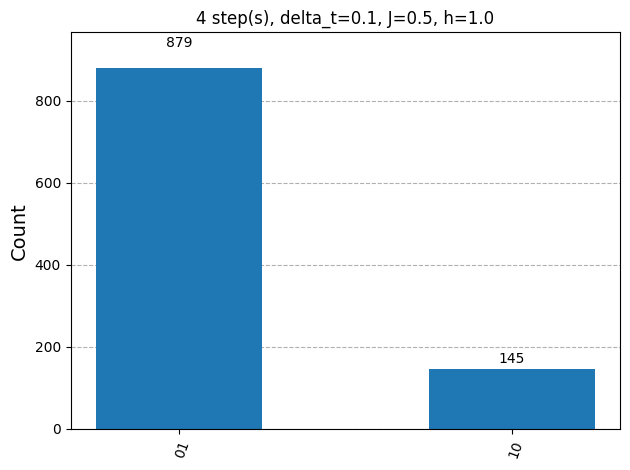

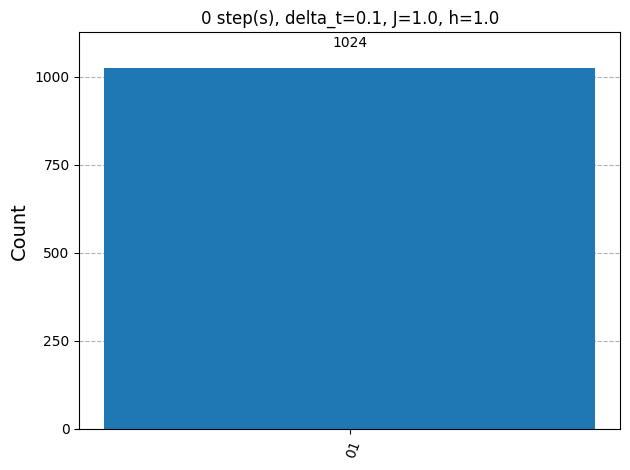

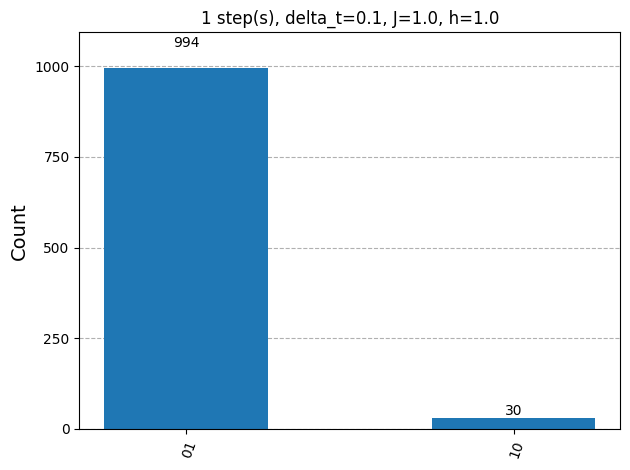

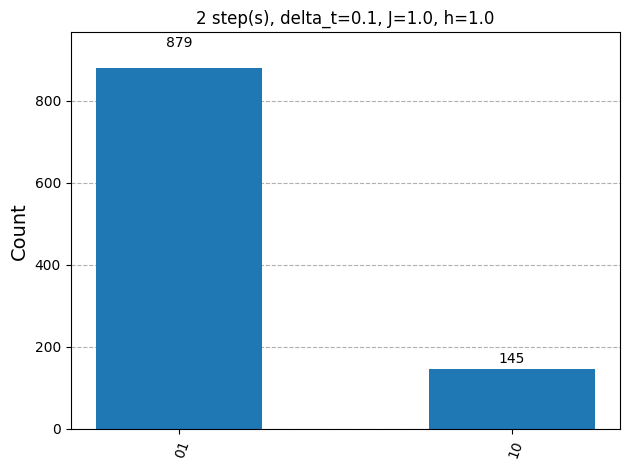

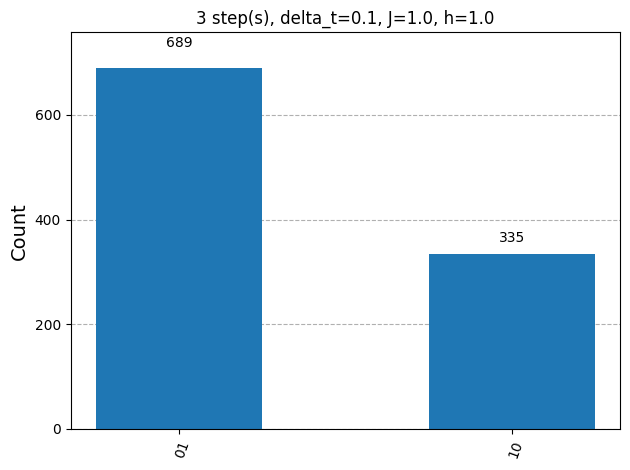

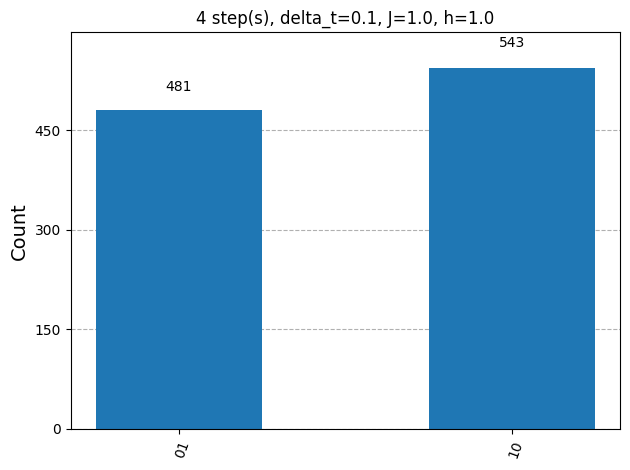

In [34]:
steps = range(0, 5) # run for 0-4 trotter steps
dt = 0.1 # time step size
J = [0.5, 1.0] # spin-spin coupling energy
h = [0.5, 1.0] # external magnetic field strength

for h_val in h:
    for J_val in J:
        for step in steps:
            # state in state |01> at t=0
            qc = QuantumCircuit(2)
            qc.x(0)
            build_time_evo_circuit(qc, step, dt, J_val, h_val)
            result = AerSimulator().run(qc).result()
            statistics = result.get_counts()
            plot_histogram(statistics, title=f"{step} step(s), delta_t={dt}, J={J_val}, h={h_val}")
            plt.show()
